# Activation Maximization for Feature Visualization in InceptionV1

This notebook demonstrates **activation maximization** — a fundamental interpretability technique for understanding what individual neurons (channels) in deep convolutional neural networks have learned to detect.

## What is Feature Visualization?

**Feature visualization** answers the question: *"What input image would make a specific neuron fire most strongly?"*

By optimizing an input image to maximize a neuron's activation, we can reverse-engineer what visual patterns that neuron has learned to detect. This helps us understand how neural networks build up their understanding of images across layers.

## The Core Idea

Neural networks are differentiable with respect to their inputs. We can use gradients to iteratively modify an input image to maximize a specific neuron's response:

1. **Start with random noise** (or a random image)
2. **Forward pass** through the network to get activations
3. **Compute gradient** of the target activation with respect to input pixels
4. **Update pixels** using gradient ascent (moving toward higher activation)
5. **Repeat** until convergence

This process reveals the "preferred stimulus" for each neuron.

## References

- [Distill: Feature Visualization](https://distill.pub/2017/feature-visualization/)
- [Lucent Library Documentation](https://github.com/TomFrederik/lucent)

---

## Setup: Import Required Libraries

We'll use the **Lucent** library, which provides high-level tools for feature visualization in PyTorch. Lucent is the PyTorch equivalent of TensorFlow's Lucid library.

Key modules:
- **`render`**: High-level interface for generating visualizations
- **`param`**: Image parameterization (pixel space vs. frequency space)
- **`transform`**: Robustness transformations (jitter, rotation, scaling)
- **`objectives`**: Loss functions (which neurons/channels to maximize)

## Load Pre-trained InceptionV1 (GoogLeNet)

**InceptionV1** (also known as GoogLeNet) is a deep CNN trained on ImageNet with 1000 object classes. It has multiple layers with increasing complexity:

- **Early layers** (conv1, conv2): Detect simple features like edges and textures
- **Mid layers** (mixed3a-4e): Detect patterns and object parts
- **Late layers** (mixed5a-5b): Detect complex objects and scenes

**Why `.eval()` mode?**
- Disables dropout (if any)
- Sets batch normalization to inference mode
- Reduces unnecessary computations

**Why disable gradients for model parameters?**
- We only want to optimize the *input image*, not the model weights
- Saves memory and computation

## Basic Feature Visualization with Lucent

**`render.render_vis()`** is the main function for generating feature visualizations. It handles:

1. **Image parameterization**: Creates a learnable tensor (default: Fourier space + decorrelation)
2. **Optimization**: Runs gradient ascent for multiple steps (default: 512)
3. **Transformations**: Applies robustness transforms (jitter, rotation, scaling)
4. **Regularization**: Prevents high-frequency noise and adversarial patterns

**Syntax**: `"layer_name:channel_index"`
- `inception4a`: A mid-level layer in InceptionV1
- `476`: The channel index to visualize

Let's visualize what channel 476 of inception4a detects:

In [28]:
import torch
from lucent.optvis import render, param, transform, objectives
import matplotlib.pyplot as plt

device = torch.device('cuda') if torch.cuda.is_available() else 'cpu'

## Visualizing Multiple Channels

**Understanding diversity across channels:**

Each channel in a layer acts as a different "feature detector". By visualizing multiple channels, we can see:
- What range of features the layer has learned
- How features become more complex in deeper layers
- Whether channels detect coherent concepts or mixtures

**About `thresholds` parameter:**
- Controls how many optimization steps to run
- `thresholds=(256,)` means optimize for 256 steps
- More steps → more refined visualizations (but slower)
- The function returns a list of images at each threshold checkpoint

Let's generate visualizations for the first 10 channels:

## Display Results in a Grid

**Interpreting the visualizations:**

Each image shows the pattern that maximally activates that channel. Look for:
- **Textures**: Repeated patterns (stripes, dots, grids)
- **Shapes**: Curves, edges, circular forms
- **Colors**: Specific color preferences
- **Object parts**: Eyes, faces, wheels (in deeper layers)

**Note**: These are *synthetic* images optimized to maximize activation, not real photos. They show the "platonic ideal" of what each neuron detects.

## Image Parameterization: The Key to Better Visualizations

**Why parameterization matters:**

Naive gradient ascent on raw pixels often produces high-frequency noise (adversarial patterns) that the network responds to but humans can't interpret.

### Three Parameterization Strategies:

#### 1. **Pixel Space** (`fft=False, decorrelate=False`)
- Directly optimize RGB pixel values
- **Problem**: Tends to create noisy, high-frequency patterns
- The network can "cheat" by finding adversarial examples

#### 2. **Fourier Space** (`fft=True, decorrelate=False`)
- Optimize in frequency domain instead of pixel space
- Naturally penalizes high frequencies
- **Better**: Produces smoother, more interpretable images
- This is called **preconditioning** in optimization

#### 3. **Fourier + Decorrelation** (`fft=True, decorrelate=True`) ✨ **Default & Best**
- Fourier basis + color decorrelation
- Colors in natural images are correlated (e.g., blue sky)
- Decorrelation makes the optimization more efficient
- **Result**: Clearest, most natural-looking visualizations

### Why This Works (The Math):

The Fourier transform decorrelates spatial frequencies, and Cholesky decomposition decorrelates color channels. This means:
- All optimization dimensions become independent
- Gradient descent becomes more efficient
- We avoid high-frequency artifacts

Let's compare all three approaches:

In [22]:
from torchvision.models import googlenet # import InceptionV1 aka GoogLeNet

model = googlenet(pretrained=True).to(device).eval() 

## Key Takeaways

### What We Learned:

1. **Feature Visualization** reveals what individual neurons have learned by generating their "ideal" input
2. **Channels** act as feature detectors, each responding to different visual patterns
3. **Parameterization** is crucial - Fourier space + decorrelation produces the best results
4. **Layers** show hierarchical learning:
   - Early: edges, colors, simple textures
   - Middle: patterns, shapes, object parts  
   - Late: complex objects and scenes

### The "Enemy" of Feature Visualization:

Without proper regularization and parameterization, optimization produces:
- High-frequency noise
- Adversarial examples
- Patterns that activate neurons but are meaningless to humans

### Solutions Applied:

✅ **Preconditioning**: Fourier basis optimization  
✅ **Decorrelation**: Independent color channels  
✅ **Transformation Robustness**: Jitter, rotation, scaling  
✅ **Regularization**: Smoothness constraints

### Further Exploration:

- Try different layers (mixed3a, mixed5b, etc.)
- Visualize specific neurons instead of whole channels
- Combine multiple neurons to see interactions
- Use diversity terms to see multiple facets of a feature

### References:

- [Distill: Feature Visualization](https://distill.pub/2017/feature-visualization/) - Comprehensive article on the technique
- [Lucent Documentation](https://github.com/TomFrederik/lucent) - PyTorch implementation
- Original papers: Erhan et al. (2009), Mordvintsev et al. (2015), Olah et al. (2017)


In [25]:
list_of_images[0][0].shape

(128, 128, 3)

In [39]:
# Generate visualizations for channels 0-9 of inception4a
layer = "inception4a"
channels = 10

visualizations_list = []
for ch in range(channels):
    print(f"Generating visualization for {layer}:{ch}")
    imgs = render.render_vis(model, f"{layer}:{ch}", show_inline=False, thresholds=(256,))
    visualizations_list.append(imgs[0][0])  # Get the final image

Generating visualization for inception4a:0


100%|██████████| 256/256 [00:34<00:00,  7.50it/s]


Generating visualization for inception4a:1


100%|██████████| 256/256 [00:30<00:00,  8.32it/s]


Generating visualization for inception4a:2


...

100%|██████████| 256/256 [00:35<00:00,  7.18it/s]


Generating visualization for inception4a:8


100%|██████████| 256/256 [00:33<00:00,  7.55it/s]


Generating visualization for inception4a:9


100%|██████████| 256/256 [00:32<00:00,  7.77it/s]


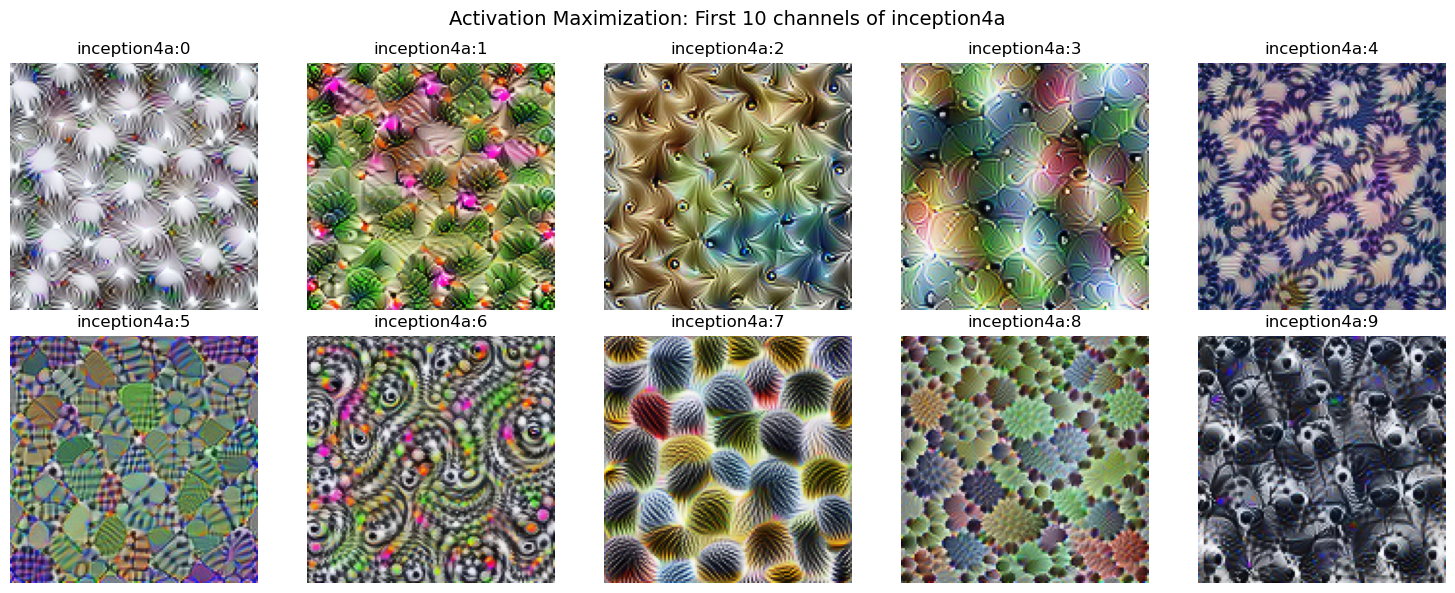

In [40]:
# Display all 10 visualizations in a grid
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i, (ax, img) in enumerate(zip(axes, visualizations_list)):
    ax.imshow(img)
    ax.set_title(f"{layer}:{i}")
    ax.axis("off")

plt.suptitle(f"Activation Maximization: First 10 channels of {layer}", fontsize=14)
plt.tight_layout()
plt.show()

  0%|          | 0/512 [00:00<?, ?it/s]

100%|██████████| 512/512 [01:18<00:00,  6.51it/s]



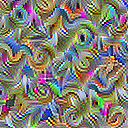

100%|██████████| 512/512 [01:06<00:00,  7.67it/s]



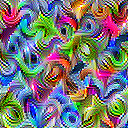

100%|██████████| 512/512 [01:05<00:00,  7.81it/s]



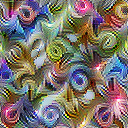

In [41]:
# the width parameter determines the image width -> influences runtime significantly
# this is vanilla RGB-parameterization
param_f = lambda: param.image(w=128, fft=False, decorrelate=False)

# using Fourier basis instead of pixel values
fft_param_f = lambda: param.image(w=128, fft=True, decorrelate=False)

# this is the default setting
fft_decor_param_f = lambda: param.image(w=128, fft=True, decorrelate=True)

# Let's see what the difference in output is:
images = []
for f in [param_f, fft_param_f, fft_decor_param_f]:
    images.append(render.render_vis(model, 'inception4a:476', param_f=f, show_inline=True))

In [32]:
param_f()

([tensor([[[[-1.0196e-03, -1.3433e-02, -1.3008e-02,  ..., -9.3538e-04,
             -1.1037e-02,  1.5210e-02],
            [-7.2202e-03, -5.6598e-03, -1.1097e-05,  ...,  9.3149e-03,
              1.3328e-03,  3.0770e-03],
            [ 2.6453e-02,  7.2110e-03,  8.8558e-03,  ..., -1.2784e-03,
              3.0654e-03,  4.0767e-03],
            ...,
            [-1.0014e-02,  4.9006e-03, -1.5783e-02,  ..., -1.2222e-02,
              3.1601e-03,  3.6549e-03],
            [-6.4479e-03,  1.9513e-02,  1.6052e-03,  ..., -1.2798e-02,
             -2.1391e-02, -7.1361e-04],
            [-1.1899e-02, -1.9272e-02, -2.2149e-02,  ...,  1.4061e-02,
              4.6974e-04, -2.7296e-02]],
  
           [[ 6.1134e-03, -5.7416e-03, -1.7417e-02,  ...,  1.7325e-02,
             -1.4890e-02,  3.1282e-03],
            [ 1.2490e-03,  6.1282e-05,  5.5813e-03,  ...,  4.1694e-03,
              6.2756e-03, -4.5584e-04],
            [-2.0422e-03,  2.7052e-03, -1.0423e-02,  ...,  2.6528e-02,
             -2.5821